# 1. Load Data

## Simple Concept

Before training a neural network, we need **data**.

The data contains:
- **Features (X)** → input information
- **Target (y)** → value the model needs to predict

Example:

| House Size | Bedrooms | Price |
|---:|---:|---:|
| 1000 | 2 | 50 |
| 1500 | 3 | 75 |
| 2000 | 4 | 100 |

Here:
- `House Size` and `Bedrooms` → Features
- `Price` → Target

`

## What This Code Does

- `data` → creates sample data.
- `pd.DataFrame(data)` → converts the data into a DataFrame.
- `df` → stores our dataset.
- `print(df)` → displays the data.

## Key Point

**Neural network training starts with data.**

`Data → Features (X) + Target (y)`

In [1]:
## Python Example
import pandas as pd

data = {
    "House_Size": [1000, 1500, 2000, 2500, 3000],
    "Bedrooms": [2, 3, 4, 4, 5],
    "Price": [50, 75, 100, 125, 150]
}

df = pd.DataFrame(data)

print(df)

   House_Size  Bedrooms  Price
0        1000         2     50
1        1500         3     75
2        2000         4    100
3        2500         4    125
4        3000         5    150


# 2. Prepare Features

## Simple Concept

After loading the data, we separate it into:

- **Features (X)** → inputs given to the neural network
- **Target (y)** → output the neural network should predict

From our example:

- `House_Size` → Feature
- `Bedrooms` → Feature
- `Price` → Target

So:

`X = House_Size + Bedrooms`

`y = Price`


## What This Code Does

```python
X = df[["House_Size", "Bedrooms"]]
```

Selects the columns that will be used as **inputs**.

```python
y = df["Price"]
```

Selects the column that the model needs to **predict**.

## Key Point

Always remember:

**X → Input Features**

**y → Target / Output**

Example:

`House Size + Bedrooms → Neural Network → Predicted Price`

In [2]:
## Python Example

X = df[["House_Size", "Bedrooms"]]
y = df["Price"]

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
   House_Size  Bedrooms
0        1000         2
1        1500         3
2        2000         4
3        2500         4
4        3000         5

Target:
0     50
1     75
2    100
3    125
4    150
Name: Price, dtype: int64


# 3. Split Data

## Simple Concept

We divide the data into two parts:

- **Training data** → used to teach the neural network.
- **Validation data** → used to check how well the model performs on unseen data.

A common split is:

`80% → Training`

`20% → Validation`


## What This Code Does

```python
test_size=0.2
```

Keeps **20% of the data for validation**.

```python
random_state=42
```

Makes the same split every time we run the code.

## Why Do We Split?

The model should not only memorize the training data.

We want to check whether it can **perform well on data it has not seen during training**.

## Key Point

`Data → Training Data + Validation Data`

**Training → Learn**

**Validation → Check**

In [3]:
## Python Example

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))


Training samples: 4
Validation samples: 1


# 4. Create Tensors

## Simple Concept

PyTorch neural networks work with **tensors**.

A tensor is simply a PyTorch data structure used to store numbers.

So, we convert our training and validation data from Pandas into PyTorch tensors.

---

## What This Code Does

```python
torch.tensor(...)
```

Converts our data into a **PyTorch tensor**.

```python
dtype=torch.float32
```

Stores the values as decimal numbers, which are commonly used for neural-network calculations.

For example:

```text
Pandas DataFrame
      ↓
PyTorch Tensor
      ↓
Neural Network
```

## Important Point

The model expects **tensors as input**, not Pandas DataFrames.

Therefore:

**Data → Features → Split → Tensors → Neural Network**

## Key Point

**Tensor = numerical data structure used by PyTorch for neural-network calculations.**

In [4]:
## Python Example

import torch

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

print(X_train_tensor)
print(y_train_tensor)


tensor([[3.0000e+03, 5.0000e+00],
        [2.0000e+03, 4.0000e+00],
        [1.0000e+03, 2.0000e+00],
        [2.5000e+03, 4.0000e+00]])
tensor([150., 100.,  50., 125.])


# 5. Create Model

## Simple Concept

Now we create the **neural network model**.

Our model will have:

`2 Inputs → Hidden Layer → 1 Output`

Because we have 2 features:

- `House_Size`
- `Bedrooms`

And we want to predict 1 value:

- `Price`

---
`

## What This Means

```text
House_Size ──┐
             ├──→ Hidden Layer (4 neurons) ──→ Price
Bedrooms ────┘
```

### `nn.Linear(2, 4)`

Means:

**2 input values → 4 neurons**

### `nn.Linear(4, 1)`

Means:

**4 hidden values → 1 output value**

The model contains **weights and biases** that will be learned during training.

## Key Point

We have now created the **structure of the neural network**.

`Input → Hidden Layer → Output`

The next steps will teach this model how to make predictions and improve its weights.

In [5]:

## Python Example
import torch.nn as nn

class HousePriceModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(2, 4)
        self.layer2 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        return x

model = HousePriceModel()

print(model)

HousePriceModel(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (layer2): Linear(in_features=4, out_features=1, bias=True)
)


# 6. Select Loss Function

## Simple Concept

A **loss function** tells us **how wrong the model's prediction is**.

Example:

```text
Actual Price     = 100
Predicted Price  = 90

Difference       = 10
```

The loss function converts this error into a **loss value**.

**Lower loss → Better prediction**

---

## Which Loss Function?

Our example is predicting **house price**, so this is a **regression problem**.

We can use **MSELoss (Mean Squared Error)**.


## What This Code Does

```python
loss_function = nn.MSELoss()
```

Creates the loss function that will measure the difference between:

**Predicted Price ↔ Actual Price**

Later, we will use it like this:

```python
loss = loss_function(prediction, y_train_tensor)
```

The resulting `loss` tells us how wrong the model is.

## Key Point

**Loss function = measures model error**

`Prediction → Compare with Actual Value → Loss`

During training, we want the **loss to decrease**.

In [6]:
## Python Example

import torch.nn as nn

loss_function = nn.MSELoss()

print(loss_function)


MSELoss()


# 7. Select Optimizer

## Simple Concept

The **optimizer** updates the model's **weights and biases** to reduce the loss.

Think of it like:

`Loss → Optimizer → Update Weights → Lower Loss`

For our neural network, we will use **Adam**.


## What This Code Does

```python
model.parameters()
```

Gets the model's **weights and biases** that need to be learned.

```python
lr=0.001
```

Sets the **learning rate**.

Learning rate controls **how big each weight update is**.

- Too high → updates may be too large
- Too low → training may be very slow

```python
optim.Adam(...)
```

Creates the Adam optimizer.

## Key Point

**Optimizer = updates model parameters to reduce loss.**

`Loss → Backpropagation → Optimizer → Weight Update`

In [7]:
## Python Example

import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# 8. Forward Pass

## Simple Concept

A **forward pass** means sending the input data through the neural network to get a prediction.

Flow:

`Input → Hidden Layer → Output → Prediction`

The model uses its current **weights and biases** to calculate the prediction.

---

## What This Code Does

```python
model(X_train_tensor)
```

Sends the training data through the neural network.

The model calculates an output for each input row.

For example:

```text
House_Size + Bedrooms
        ↓
   Neural Network
        ↓
 Predicted Price
```

At this stage, the model has **not updated its weights yet**.

It has only made predictions using its current weights.

## Key Point

**Forward pass = model makes a prediction.**

`Input → Model → Prediction`

The next step is to compare this prediction with the actual value and calculate the **loss**.

In [8]:

## Python Example

prediction = model(X_train_tensor)

print(prediction)



tensor([[-729.2625],
        [-486.0956],
        [-243.1509],
        [-607.7900]], grad_fn=<AddmmBackward0>)


# 9. Calculate Loss

## Simple Concept

After the **forward pass**, the model has made predictions.

Now we compare:

**Predicted Value ↔ Actual Value**

The loss function tells us **how wrong the prediction is**.

For our regression problem, we use **MSE Loss**.

---


## What This Code Does

```python
prediction = model(X_train_tensor)
```

The model makes predictions.

```python
loss = loss_function(prediction, y_train_tensor)
```

Compares the predictions with the actual prices.

```python
loss.item()
```

Converts the PyTorch loss value into a normal Python number.

## Simple Flow

```text
Input Data
    ↓
Forward Pass
    ↓
Prediction
    ↓
Compare with Actual Value
    ↓
Calculate Loss
```

## Important Point

A **high loss** means the predictions are far from the actual values.

A **low loss** means the predictions are closer to the actual values.

During training, we generally want:

`Loss ↓`

In [9]:
## Python Example

prediction = model(X_train_tensor)

loss = loss_function(prediction, y_train_tensor)

print("Loss:", loss.item())


Loss: 421589.3125


C:\Users\nanda\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:630: UserWarning: Using a target size (torch.Size([4])) that is different to the input size (torch.Size([4, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


# 10. Backpropagation

## Simple Concept

**Backpropagation** tells the neural network **how its weights contributed to the error**.

After calculating the loss:

`Prediction → Loss → Backpropagation`

Backpropagation calculates the **gradients** of the model's parameters.

These gradients tell the optimizer **which direction the weights should change** to reduce the loss.

---

## What This Code Does

```python
loss.backward()
```

Calculates the **gradients** for the model's weights and biases.

These gradients are then used by the optimizer in the next step.

The complete flow is:

```text
Forward Pass
     ↓
Prediction
     ↓
Calculate Loss
     ↓
Backpropagation
     ↓
Gradients
     ↓
Update Weights
```

## Key Point

**Backpropagation = calculates gradients that tell the optimizer how to adjust the model parameters.**

In [11]:

## Python Example

loss.backward()



# 11. Update Weights

## Simple Concept

After backpropagation calculates the **gradients**, the optimizer uses them to update the model's **weights and biases**.

The goal is:

**Reduce the loss → Improve predictions**

---
`

## What This Code Does

```python
optimizer.step()
```

Tells the optimizer to update the model's parameters using the gradients calculated during backpropagation.

The basic training flow is:

```text
Forward Pass
     ↓
Calculate Loss
     ↓
Backpropagation
     ↓
Calculate Gradients
     ↓
Update Weights
```

## Simple Understanding

Suppose the model predicts:

```text
Actual Price     = 100
Predicted Price  = 80
```

There is an error.

Backpropagation calculates the gradients, and the optimizer uses them to **adjust the weights** so that future predictions can become better.

## Key Point

**Optimizer step = update the model's weights and biases.**

`loss.backward()` → calculates gradients

`optimizer.step()` → updates weights

In [12]:

## Python Example

optimizer.step()

# 12. Epoch, Batch & Iteration

## Simple Concept

During training, the model sees the training data **multiple times**.

Three important terms are:

### Epoch

One **complete pass through the entire training dataset**.

Example:

```text
100 training samples
1 epoch = model sees all 100 samples once
```

### Batch

A **small group of training samples** processed together.

Example:

```text
100 samples
Batch size = 20

Batch 1 → 20 samples
Batch 2 → 20 samples
Batch 3 → 20 samples
...
```

### Iteration

One **batch processed by the model**.

So:

```text
1 Iteration = 1 Batch processed
```

---

## Simple Example

Suppose we have:

```text
100 training samples
Batch size = 20
```

Then:

```text
100 ÷ 20 = 5 iterations per epoch
```

So:

```text
1 Epoch
    ↓
5 Iterations
    ↓
Each iteration processes 20 samples
```

If we train for **10 epochs**:

```text
10 Epochs × 5 Iterations = 50 Iterations
```

---

## Key Point

Remember it like this:

**Epoch → Entire dataset**

**Batch → Small portion of dataset**

**Iteration → One batch processed**

# 13. Complete Training Loop

## Simple Concept

Now we combine the steps we learned into one **training loop**.

For every epoch, the model:

`Forward Pass → Calculate Loss → Backpropagation → Update Weights`

We also use `optimizer.zero_grad()` to clear the old gradients before calculating new ones.

---

## What Happens in One Epoch?

```text
1. Clear old gradients
        ↓
2. Forward Pass
        ↓
3. Calculate Loss
        ↓
4. Backpropagation
        ↓
5. Update Weights
```

This process repeats for every epoch.

---

## Important

```python
optimizer.zero_grad()
```

Clears the gradients from the previous iteration.

```python
loss.backward()
```

Calculates new gradients.

```python
optimizer.step()
```

Updates the weights and biases.

---

## Key Point

The **training loop** is the main process that teaches the neural network.

`Repeat → Forward → Loss → Backpropagation → Weight Update`

for multiple **epochs**.

In [13]:

## Python Example

epochs = 100

for epoch in range(epochs):

    # Clear previous gradients
    optimizer.zero_grad()

    # Forward pass
    prediction = model(X_train_tensor)

    # Calculate loss
    loss = loss_function(prediction, y_train_tensor)

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 347275.6875
Epoch 20, Loss: 281340.6562
Epoch 30, Loss: 224227.9062
Epoch 40, Loss: 175819.0938
Epoch 50, Loss: 135589.9844
Epoch 60, Loss: 102784.9844
Epoch 70, Loss: 76545.0234
Epoch 80, Loss: 55983.4297
Epoch 90, Loss: 40228.2305
Epoch 100, Loss: 28448.2930


C:\Users\nanda\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:630: UserWarning: Using a target size (torch.Size([4])) that is different to the input size (torch.Size([4, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


# 14. Training Loss vs Epoch

## Simple Concept

During training, we record the **loss after each epoch**.

Then we plot:

**Training Loss vs Epoch**

This helps us see whether the model is **learning**.

Normally, we expect:

`Epoch increases → Training Loss decreases`

---


## What the Graph Shows

```text
Loss
 ↑
 |\
 | \
 |  \
 |   \____
 |
 +----------------→ Epoch
```

A decreasing curve usually means the model is **learning from the training data**.

### If Loss Decreases

The model's predictions are generally getting closer to the training targets.

### If Loss Stops Decreasing

The model may have reached a point where additional training is giving little improvement.

### If Loss Increases

The training process may have a problem, such as an unsuitable learning rate or other training settings.

## Key Point

**Training Loss Curve = shows how the model's error changes during training.**

`Good learning → Training loss generally decreases`

C:\Users\nanda\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:630: UserWarning: Using a target size (torch.Size([4])) that is different to the input size (torch.Size([4, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


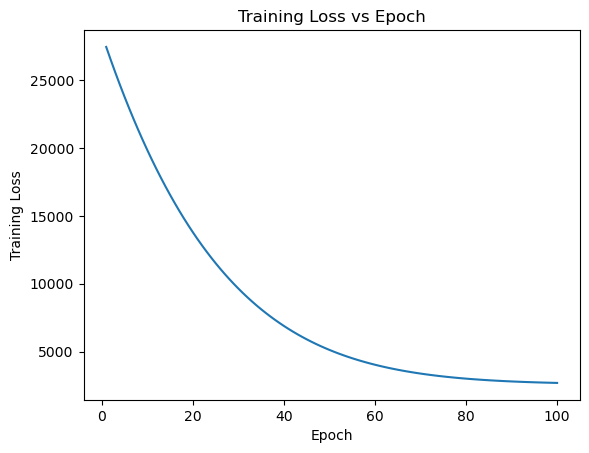

In [14]:

## Python Example

import matplotlib.pyplot as plt

epochs = []
training_losses = []

for epoch in range(100):

    optimizer.zero_grad()

    prediction = model(X_train_tensor)

    loss = loss_function(prediction, y_train_tensor)

    loss.backward()

    optimizer.step()

    epochs.append(epoch + 1)
    training_losses.append(loss.item())

plt.plot(epochs, training_losses)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")

plt.show()

# 15. Validation Loss vs Epoch

## Simple Concept

**Validation loss** measures how well the model performs on **validation data that was not used to update the weights**.

We calculate it after each epoch.

This helps us check whether the model is **generalizing to unseen data**.

---

## What This Code Does

```python
with torch.no_grad():
```

Tells PyTorch that we are only **checking the model**.

We do not need gradients or weight updates during validation.

```python
val_prediction = model(X_val_tensor)
```

Makes predictions using the validation data.

```python
val_loss = loss_function(val_prediction, y_val_tensor)
```

Calculates the validation loss.

---


## What the Curve Indicates

### Validation Loss Decreases

The model is generally improving on unseen validation data.

### Validation Loss Starts Increasing

Training loss may continue decreasing while validation loss increases.

This can be a sign of **overfitting**.

```text
Training Loss ↓
Validation Loss ↑
        ↓
Possible Overfitting
```

## Key Point

**Validation Loss Curve = shows how well the model generalizes to unseen data.**

C:\Users\nanda\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:630: UserWarning: Using a target size (torch.Size([4])) that is different to the input size (torch.Size([4, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\nanda\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:630: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


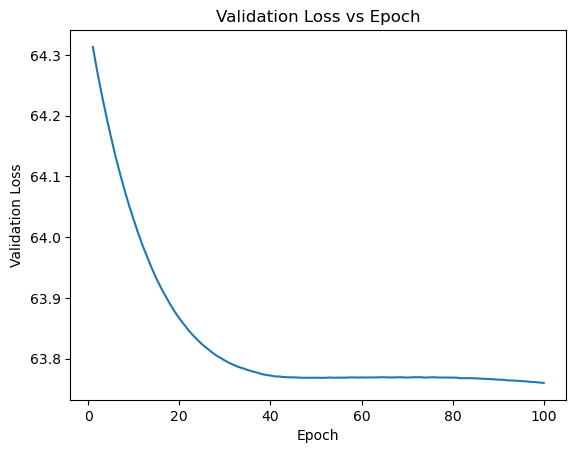

In [17]:

## Python Example

validation_losses = []

for epoch in range(100):

    optimizer.zero_grad()

    # Training
    prediction = model(X_train_tensor)
    loss = loss_function(prediction, y_train_tensor)

    loss.backward()
    optimizer.step()

    # Validation
    with torch.no_grad():
        val_prediction = model(X_val_tensor)
        val_loss = loss_function(val_prediction, y_val_tensor)

    validation_losses.append(val_loss.item())

## Plot Validation Loss

import matplotlib.pyplot as plt

plt.plot(range(1, 101), validation_losses)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")

plt.show()
